In [1]:
import pandas as pd
df = pd.read_csv("retail_ab_test_10000.csv")
df.head()

,customer_id,week,experiment_group,region,device,traffic_source,loyalty_tier,age,income_k,prior_3mo_visits,prior_3mo_spend,session_duration_sec,pages_viewed,cart_adds,purchased,order_value,discount_applied,shipping_cost,returned,satisfaction_score
0,180325,12,Discount10,West,mobile,organic,Bronze,25,84.0,4,119.32,228,6,2,0,0.00,0.0,0.00,0,2
1,796559,28,Control,Northeast,tablet,organic,Silver,67,37.7,2,82.31,134,4,0,1,43.06,0.0,6.77,0,3
2,689113,35,Control,South,mobile,organic,Bronze,24,92.2,5,155.35,121,4,1,0,0.00,0.0,0.00,0,4
3,494990,14,Control,Midwest,mobile,affiliate,Silver,49,118.2,1,368.48,169,4,0,0,0.00,0.0,0.00,0,3
4,489713,40,Control,South,mobile,social,Bronze,52,99.5,6,128.10,362,7,2,0,0.00,0.0,0.00,0,3


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           10000 non-null  int64  
 1   week                  10000 non-null  int64  
 2   experiment_group      10000 non-null  object 
 3   region                10000 non-null  object 
 4   device                10000 non-null  object 
 5   traffic_source        10000 non-null  object 
 6   loyalty_tier          10000 non-null  object 
 7   age                   10000 non-null  int64  
 8   income_k              10000 non-null  float64
 9   prior_3mo_visits      10000 non-null  int64  
 10  prior_3mo_spend       10000 non-null  float64
 11  session_duration_sec  10000 non-null  int64  
 12  pages_viewed          10000 non-null  int64  
 13  cart_adds             10000 non-null  int64  
 14  purchased             10000 non-null  int64  
 15  order_value         

In [3]:
df[['order_value']].describe()


,order_value
count,10000.000000
mean,6.120052
std,18.069235
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,128.090000


In [4]:
df_purch = df[df['order_value'] > 0]
df_purch.describe()


,customer_id,week,age,income_k,prior_3mo_visits,prior_3mo_spend,session_duration_sec,pages_viewed,cart_adds,purchased,order_value,discount_applied,shipping_cost,returned,satisfaction_score
count,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.0,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,535273.993860,26.507291,37.152724,68.680967,6.002302,141.597153,268.020721,5.059862,1.009977,1.0,46.968933,0.037299,4.867291,0.080583,4.135073
std,263687.561912,14.892283,11.375473,24.692901,2.772893,100.757774,167.983675,2.246576,1.007983,0.0,24.234410,0.048378,3.298322,0.272299,0.657129
min,100578.000000,1.000000,18.000000,20.000000,0.000000,1.870000,32.000000,1.000000,0.000000,1.0,0.220000,0.000000,0.000000,0.000000,2.000000
25%,306749.500000,14.000000,29.000000,51.500000,4.000000,69.415000,157.000000,3.000000,0.000000,1.0,28.670000,0.000000,0.840000,0.000000,4.000000
50%,527519.000000,27.000000,37.000000,64.400000,6.000000,117.730000,232.000000,5.000000,1.000000,1.0,45.610000,0.000000,5.580000,0.000000,4.000000
75%,765771.500000,40.000000,45.000000,81.550000,8.000000,193.295000,329.000000,6.000000,2.000000,1.0,63.280000,0.100000,7.260000,0.000000,5.000000
max,999742.000000,52.000000,74.000000,192.100000,17.000000,647.350000,1921.000000,16.000000,6.000000,1.0,128.090000,0.100000,12.660000,1.000000,5.000000


In [5]:
df_purch.corr(numeric_only=True)['order_value'].sort_values(ascending=False)


order_value             1.000000
prior_3mo_spend         0.150856
income_k                0.138898
cart_adds               0.134673
pages_viewed            0.107161
prior_3mo_visits        0.071234
session_duration_sec    0.059983
returned                0.043796
discount_applied        0.012913
shipping_cost          -0.003652
customer_id            -0.007016
week                   -0.008999
age                    -0.010741
satisfaction_score     -0.038614
purchased                    NaN
Name: order_value, dtype: float64

In [6]:
X = df_purch[['income_k','prior_3mo_spend','prior_3mo_visits',
              'session_duration_sec','pages_viewed','cart_adds']]

y = df_purch['order_value']

X.head()


,income_k,prior_3mo_spend,prior_3mo_visits,session_duration_sec,pages_viewed,cart_adds
1,37.7,82.31,2,134,4,0
23,122.6,148.28,5,253,4,0
32,47.9,31.87,9,226,6,0
37,59.8,30.62,9,497,7,2
40,52.4,223.48,7,221,5,1


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1042, 6)
(261, 6)
(1042,)
(261,)


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = model.predict(X_test)


In [11]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.04648789050618518
RMSE: 22.798157338354258
MAE: 18.61480126619903


## Random Forest Model

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate model
r2_rf = r2_score(y_test, y_pred_rf)
import numpy as np
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Random Forest Results:
R2: -0.07752791720293661
RMSE: 24.235439816907913
MAE: 19.664159003831415


In [13]:
print("Model Comparison:\n")

print("Linear Regression:")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

print("\nRandom Forest:")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Model Comparison:

Linear Regression:
R2: 0.04648789050618518
RMSE: 22.798157338354258
MAE: 18.61480126619903

Random Forest:
R2: -0.07752791720293661
RMSE: 24.235439816907913
MAE: 19.664159003831415


## Feature Importance (Random Forest)

prior_3mo_spend         0.245999
income_k                0.245054
session_duration_sec    0.236575
prior_3mo_visits        0.113495
pages_viewed            0.093994
cart_adds               0.064883
dtype: float64


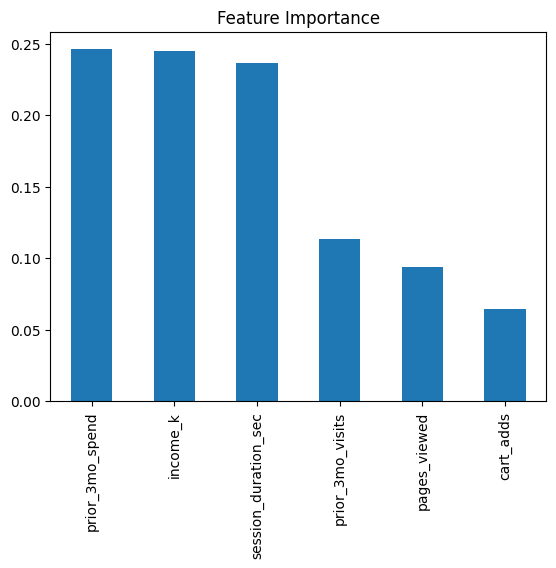

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

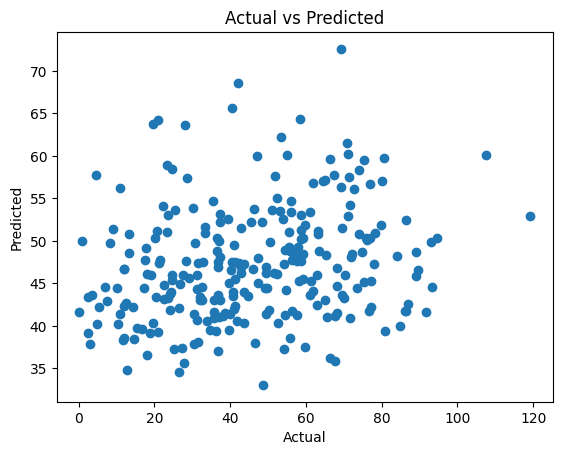

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients


,Feature,Coefficient
5,cart_adds,3.195199
4,pages_viewed,0.728460
2,prior_3mo_visits,0.419904
0,income_k,0.149782
1,prior_3mo_spend,0.038257
3,session_duration_sec,0.004585


In [17]:
print(model.coef_)
print(model.intercept_)
print(r2_score(y_test, y_pred))

[0.14978155 0.03825746 0.41990401 0.00458505 0.72846044 3.19519898]
20.90570656748866
0.04648789050618518


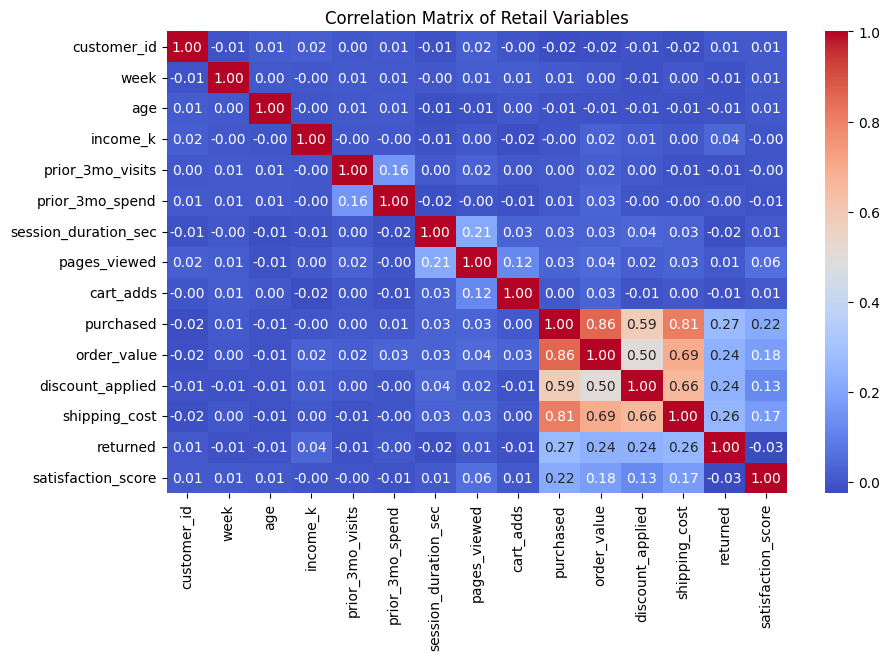

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Retail Variables")
plt.show()

## Conclusion

This analysis evaluated both linear and nonlinear models to predict retail revenue.

Linear regression produced low explanatory power (R² ≈ 0.046), and Random Forest performed worse (R² < 0), indicating that more complex models did not improve predictive performance.

Feature importance analysis showed that prior spending behavior and income were the most influential variables, while engagement metrics had less impact than expected.

These results suggest that the available dataset lacks key variables needed to accurately predict revenue, and that retail purchasing behavior is influenced by factors not captured in basic demographic and session-level data.